In [1]:
import os
import cv2
import json
import joblib
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
 
import sklearn, sys
# PCA diganti dengan Autoencoder (AE) — tidak perlu sklearn.decomposition
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity
from skimage.feature import hog
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
 
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import HandLandmarker, HandLandmarkerOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode
 
from roi_mediapipe import detect_palm_opencv
 
warnings.filterwarnings('ignore')
 
 
print(f"sklearn : {sklearn.__version__}")
print(f"torch   : {torch.__version__}")
print(f"python  : {sys.executable}")

sklearn : 1.7.2
torch   : 2.10.0+cpu
python  : c:\python313\python.exe


### BAGIAN 1 — KONFIGURASI

In [2]:
class Config:
    DATASET_PATH = r'D:\xampp\htdocs\palmprint-backend\palmprint-ml\dataset'
    OUTPUT_PATH  = 'results'
    MODELS_DIR   = 'models'
 
    # ROI
    ROI_SIZE   = 200
    IMAGE_SIZE = 64          # resize sebelum HOG (paper: 64×64)
 
    # HOG
    HOG_ORIENT = 9
    HOG_PIXELS = 8          # pixels per cell
    HOG_CELLS  = 2           # cells per block
 
    # SGF — 24 orientasi, step 15°
    SGF_ANGLES = np.deg2rad(np.arange(0, 360, 15))
 
    # CLAHE
    CLAHE_CLIP = 2.0
    CLAHE_TILE = (8, 8)
 
    # Gabor
    GABOR_KSIZE  = 21
    GABOR_SIGMA  = 4.0
    GABOR_LAMBDA = 10.0
    GABOR_GAMMA  = 0.5
    GABOR_THETAS = [0, np.pi/4, np.pi/2, 3*np.pi/4]
 
    # PCA — jumlah komponen dipilih otomatis berdasarkan variance
    PCA_VARIANCE = 0.99
 
    # Skin detection (YCrCb)
    SKIN_LOWER_YCR = np.array([0,   133,  77], dtype=np.uint8)
    SKIN_UPPER_YCR = np.array([255, 173, 127], dtype=np.uint8)
 
 
for d in [Config.OUTPUT_PATH, Config.MODELS_DIR]:
    os.makedirs(d, exist_ok=True)
 
print('✓ Konfigurasi siap')
print(f'  Dataset  : {Config.DATASET_PATH}')
print(f'  PCA      : {int(Config.PCA_VARIANCE * 100)}% variance otomatis')
print(f'  HOG      : orient={Config.HOG_ORIENT}, cell={Config.HOG_PIXELS}px, block={Config.HOG_CELLS}cells')

✓ Konfigurasi siap
  Dataset  : D:\xampp\htdocs\palmprint-backend\palmprint-ml\dataset
  PCA      : 99% variance otomatis
  HOG      : orient=9, cell=8px, block=2cells


### BAGIAN 2 — PREPROCESSING: NORMALISASI PENCAHAYAAN + GABOR ENHANCEMENT

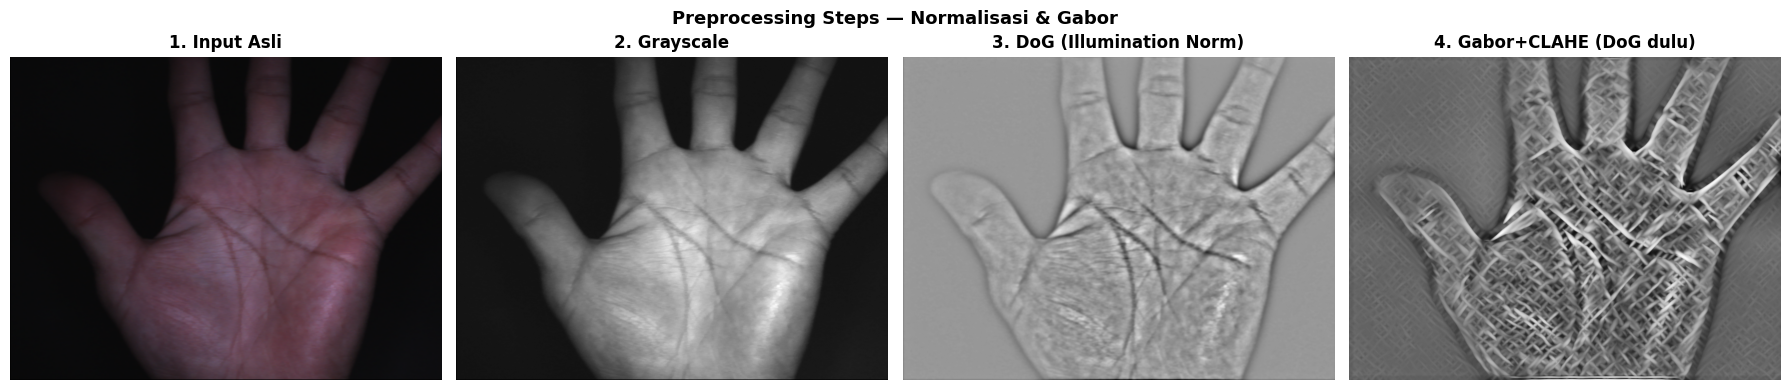

✓ Visualisasi preprocessing selesai


In [3]:
def normalize_illumination(img_gray):
    """
    Normalisasi pencahayaan dengan Difference of Gaussians (DoG).
 
    Masalah: Foto dari HP punya variasi brightness (terang/gelap/bayangan).
    Solusi : DoG memisahkan tekstur dari pencahayaan global.
 
    Cara kerja:
        DoG = Gaussian(σ=1) - Gaussian(σ=10)
        σ=1  → tangkap detail halus (~3px)
        σ=10 → tangkap cahaya global (~30px)
        Selisihnya = tekstur murni, bebas pencahayaan global
 
    Kenapa bukan CLAHE saja:
        CLAHE meningkatkan kontras lokal tapi tidak menghilangkan variasi
        pencahayaan global. DoG benar-benar memisahkan keduanya.
    """
    img_f   = img_gray.astype(np.float32)
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=1.0)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=10.0)
    dog     = g_small - g_large
    return cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
 
 
def enhance_gabor(img_gray, ksize=None, sigma=None, lambd=None,
                  gamma=None, thetas=None, use_dog=False):
    """
    Gabor filter bank multi-orientasi + CLAHE.
 
    Args:
        use_dog : jika True, jalankan normalize_illumination sebelum Gabor
    """
    ksize  = ksize  or Config.GABOR_KSIZE
    sigma  = sigma  or Config.GABOR_SIGMA
    lambd  = lambd  or Config.GABOR_LAMBDA
    gamma  = gamma  or Config.GABOR_GAMMA
    thetas = thetas or Config.GABOR_THETAS
 
    if use_dog:
        img_gray = normalize_illumination(img_gray)
 
    responses = []
    for theta in thetas:
        kernel = cv2.getGaborKernel(
            ksize=(ksize, ksize), sigma=sigma, theta=theta,
            lambd=lambd, gamma=gamma, psi=0, ktype=cv2.CV_32F
        )
        resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
        responses.append(np.abs(resp))
 
    gabor_max = np.max(responses, axis=0)
    gabor_max = cv2.normalize(gabor_max, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe     = cv2.createCLAHE(clipLimit=Config.CLAHE_CLIP, tileGridSize=Config.CLAHE_TILE)
    return clahe.apply(gabor_max)
 
 
# ── Visualisasi preprocessing pada 1 sample ──
exts    = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
samples = [f for f in os.listdir(Config.DATASET_PATH) if f.lower().endswith(exts)]
 
if samples:
    img_s    = cv2.imread(os.path.join(Config.DATASET_PATH, samples[0]))
    gray_s   = cv2.cvtColor(img_s, cv2.COLOR_BGR2GRAY)
    dog_s    = normalize_illumination(gray_s)
    gabor_s  = enhance_gabor(gray_s, use_dog=False)
    gabor_dog_s = enhance_gabor(gray_s, use_dog=True)
 
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle('Preprocessing Steps — Normalisasi & Gabor', fontsize=13, fontweight='bold')
 
    axes[0].imshow(cv2.cvtColor(img_s, cv2.COLOR_BGR2RGB))
    axes[0].set_title('1. Input Asli', fontweight='bold'); axes[0].axis('off')
 
    axes[1].imshow(gray_s, cmap='gray')
    axes[1].set_title('2. Grayscale', fontweight='bold'); axes[1].axis('off')
 
    axes[2].imshow(dog_s, cmap='gray')
    axes[2].set_title('3. DoG (Illumination Norm)', fontweight='bold'); axes[2].axis('off')
 
    axes[3].imshow(gabor_dog_s, cmap='gray')
    axes[3].set_title('4. Gabor+CLAHE (DoG dulu)', fontweight='bold'); axes[3].axis('off')
 
    plt.tight_layout()
    plt.show()
    print('✓ Visualisasi preprocessing selesai')

### BAGIAN 3 — AUGMENTASI ROI (TRAINING ONLY)

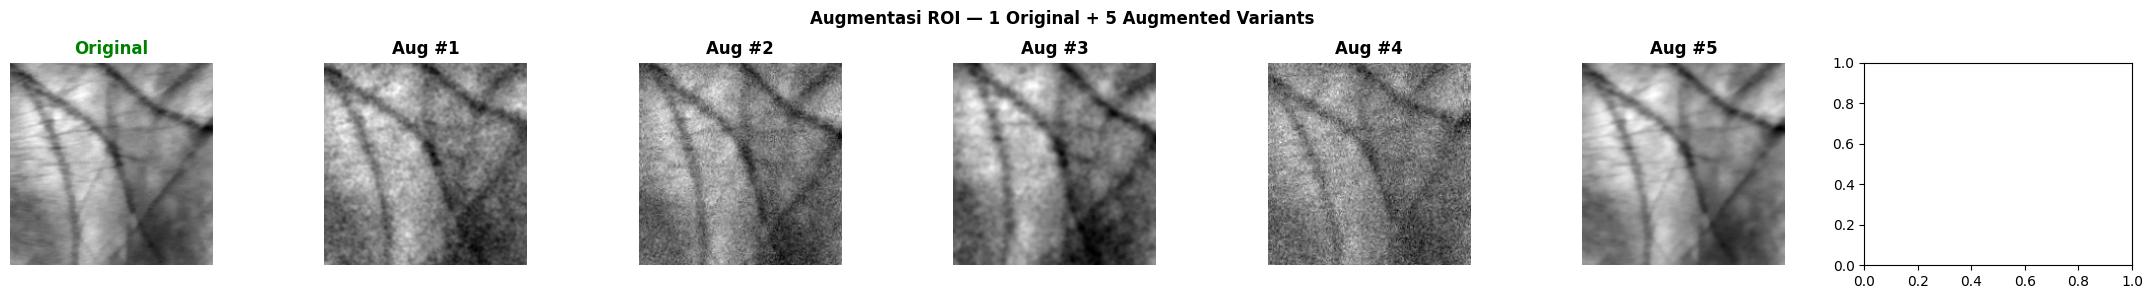

✓ Visualisasi augmentasi selesai


In [4]:
def augment_roi(roi_gray, n_aug=3):
    """
    Augmentasi ROI palmprint untuk memperbanyak data training.

    Augmentasi yang DIPILIH (aman untuk palmprint):
      1. Brightness shift ±30     → simulasi variasi cahaya HP
      2. Contrast scaling 0.8–1.2 → simulasi variasi exposure
      3. Gaussian noise σ=5–15    → simulasi noise sensor kamera
      4. Gaussian blur σ=0.5–1.5  → simulasi slight defocus
      5. Rotasi kecil ±10°        → toleransi sisa error alignment
      6. Random crop ±15px        → toleransi pergeseran centroid

    Augmentasi yang DIHINDARI:
      - Flip horizontal/vertikal  → garis tangan kiri ≠ kanan
      - Rotasi besar (>20°)       → sudah ditangani alignment
      - Elastic distortion        → merusak struktur garis palmprint

    Args:
        roi_gray : grayscale ROI (np.uint8), ukuran ROI_SIZE × ROI_SIZE
        n_aug    : jumlah augmentasi per gambar (total dataset = n_aug+1 x)

    Returns:
        list of np.uint8 : ROI hasil augmentasi (tidak termasuk original)
    """
    h, w = roi_gray.shape[:2]
    results = []

    for _ in range(n_aug):
        aug = roi_gray.copy().astype(np.float32)

        # 1. Brightness shift
        if np.random.random() < 0.5:
            aug = np.clip(aug + np.random.uniform(-30, 30), 0, 255)

        # 2. Contrast scaling
        if np.random.random() < 0.4:
            aug = np.clip(aug * np.random.uniform(0.8, 1.2), 0, 255)

        # 3. Gaussian noise
        if np.random.random() < 0.5:
            noise = np.random.normal(0, np.random.uniform(5, 15), aug.shape)
            aug = np.clip(aug + noise, 0, 255)

        # 4. Gaussian blur ringan
        if np.random.random() < 0.4:
            aug = cv2.GaussianBlur(aug, (0, 0), np.random.uniform(0.5, 1.5))

        # 5. Rotasi kecil ±10°
        if np.random.random() < 0.6:
            angle = np.random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
            aug = cv2.warpAffine(
                aug, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT
            )

        # 6. Random crop + resize balik
        if np.random.random() < 0.5:
            margin = 15
            x1 = np.random.randint(0, margin)
            y1 = np.random.randint(0, margin)
            x2 = w - np.random.randint(0, margin)
            y2 = h - np.random.randint(0, margin)
            aug = cv2.resize(aug[y1:y2, x1:x2], (w, h), interpolation=cv2.INTER_LINEAR)

        results.append(aug.astype(np.uint8))

    return results


# ── Visualisasi augmentasi pada 1 sample ROI ──
if samples:
    roi_s, _ = detect_palm_opencv(img_s)
    aug_samples = augment_roi(roi_s, n_aug=5)

    fig, axes = plt.subplots(1, 7, figsize=(22, 3))
    fig.suptitle(
        "Augmentasi ROI — 1 Original + 5 Augmented Variants",
        fontsize=12,
        fontweight="bold",
    )

    axes[0].imshow(roi_s, cmap="gray")
    axes[0].set_title("Original", fontweight="bold", color="green")
    axes[0].axis("off")

    for i, aug_roi in enumerate(aug_samples):
        axes[i + 1].imshow(aug_roi, cmap="gray")
        axes[i + 1].set_title(f"Aug #{i+1}", fontweight="bold")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()
    print("✓ Visualisasi augmentasi selesai")

### BAGIAN 4 — EKSTRAKSI FITUR HOG-SGF

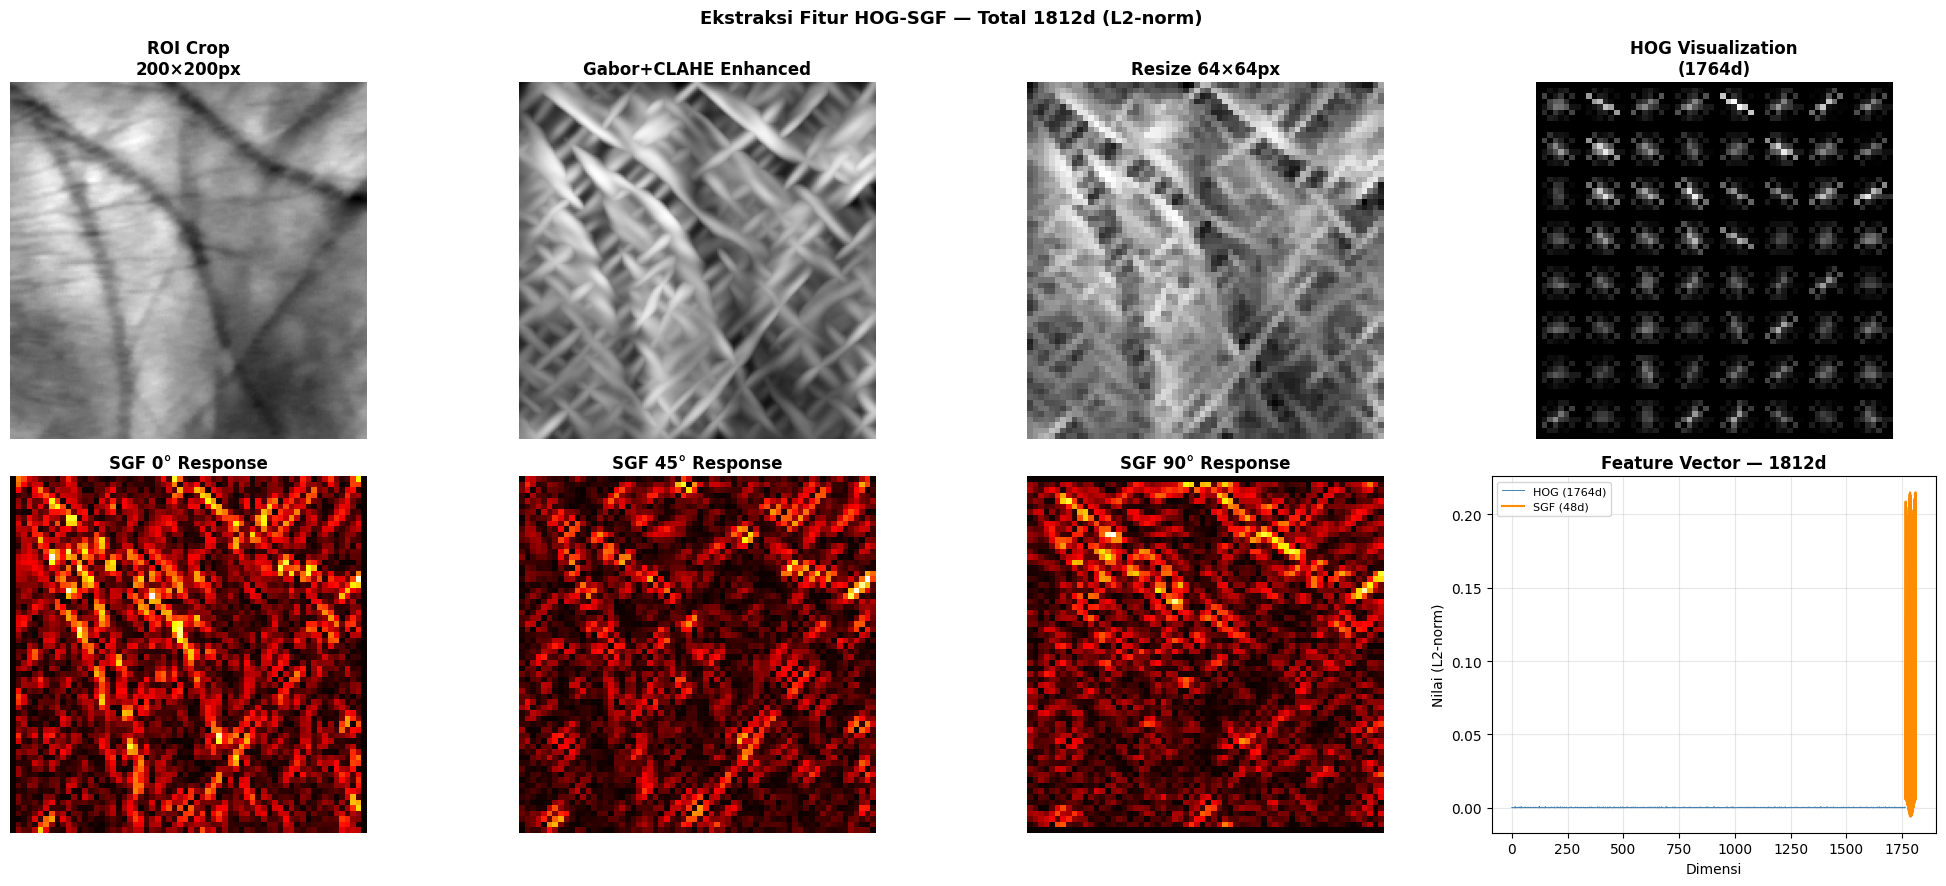

✓ HOG-SGF feature dim: 1812 (1764d HOG + 48d SGF)


In [5]:
def extract_hog_sgf(img_gray, hog_orient=None, hog_pixels=None,
                    hog_cells=None, visualize=False):
    """
    Ekstraksi fitur HOG-SGF sesuai paper.
 
    Dimensi output:
      HOG : 1764 dim  (default config)
      SGF :   48 dim  (24 sudut × mean + std)
      Total: 1812 dim, di-L2-normalize
 
    Args:
        visualize : jika True, kembalikan juga hog_img, img_64, Ix, Iy
    """
    orient = hog_orient or Config.HOG_ORIENT
    pixels = hog_pixels or Config.HOG_PIXELS
    cells  = hog_cells  or Config.HOG_CELLS
 
    img_64 = cv2.resize(img_gray, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))
 
    # ── HOG ──
    if visualize:
        hog_feat, hog_img = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels), cells_per_block=(cells, cells),
            block_norm='L2', visualize=True
        )
    else:
        hog_feat = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels), cells_per_block=(cells, cells),
            block_norm='L2', visualize=False
        )
        hog_img = None
 
    # ── SGF ──
    img_f = img_64.astype(np.float32)
    Ix    = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    Iy    = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)
 
    sgf_feats = []
    for theta in Config.SGF_ANGLES:
        FR = np.cos(theta) * Ix + np.sin(theta) * Iy
        sgf_feats.extend([np.mean(FR), np.std(FR)])
 
    sgf_feat = np.array(sgf_feats, dtype=np.float32)   # 48 dim
 
    # ── Gabung + L2 normalize ──
    combined = np.concatenate([hog_feat, sgf_feat])
    norm     = np.linalg.norm(combined)
    if norm > 0:
        combined = combined / norm
 
    if visualize:
        return combined, hog_img, img_64, Ix, Iy
    return combined
 
 
# ── Visualisasi ekstraksi fitur pada 1 sample ──
if samples:
    enh_s   = enhance_gabor(roi_s)
    feat_s, hog_img_s, img64_s, Ix_s, Iy_s = extract_hog_sgf(enh_s, visualize=True)
 
    hog_dim = len(feat_s) - len(Config.SGF_ANGLES) * 2
    sgf_dim = len(Config.SGF_ANGLES) * 2
 
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(f'Ekstraksi Fitur HOG-SGF — Total {len(feat_s)}d (L2-norm)', fontsize=13, fontweight='bold')
 
    # Row 0: tahapan gambar
    axes[0, 0].imshow(roi_s, cmap='gray')
    axes[0, 0].set_title(f'ROI Crop\n{Config.ROI_SIZE}×{Config.ROI_SIZE}px', fontweight='bold')
    axes[0, 0].axis('off')
 
    axes[0, 1].imshow(enh_s, cmap='gray')
    axes[0, 1].set_title('Gabor+CLAHE Enhanced', fontweight='bold')
    axes[0, 1].axis('off')
 
    axes[0, 2].imshow(img64_s, cmap='gray')
    axes[0, 2].set_title(f'Resize {Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}px', fontweight='bold')
    axes[0, 2].axis('off')
 
    axes[0, 3].imshow(hog_img_s, cmap='gray')
    axes[0, 3].set_title(f'HOG Visualization\n({hog_dim}d)', fontweight='bold')
    axes[0, 3].axis('off')
 
    # Row 1: SGF orientasi + feature vector
    sgf_angles_vis = [0, np.pi/4, np.pi/2]
    sgf_labels_vis = ['SGF 0°', 'SGF 45°', 'SGF 90°']
    for col, (theta, lbl) in enumerate(zip(sgf_angles_vis, sgf_labels_vis)):
        FR   = np.cos(theta) * Ix_s + np.sin(theta) * Iy_s
        FR_n = cv2.normalize(np.abs(FR), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        axes[1, col].imshow(FR_n, cmap='hot')
        axes[1, col].set_title(f'{lbl} Response', fontweight='bold')
        axes[1, col].axis('off')
 
    axes[1, 3].plot(feat_s[:hog_dim], lw=0.7, color='steelblue', label=f'HOG ({hog_dim}d)')
    axes[1, 3].plot(range(hog_dim, hog_dim + sgf_dim),
                    feat_s[hog_dim:], lw=1.5, color='darkorange', label=f'SGF ({sgf_dim}d)')
    axes[1, 3].set_title(f'Feature Vector — {len(feat_s)}d', fontweight='bold')
    axes[1, 3].legend(fontsize=8)
    axes[1, 3].grid(True, alpha=0.3)
    axes[1, 3].set_xlabel('Dimensi')
    axes[1, 3].set_ylabel('Nilai (L2-norm)')
 
    plt.tight_layout()
    plt.show()
    print(f'✓ HOG-SGF feature dim: {len(feat_s)} ({hog_dim}d HOG + {sgf_dim}d SGF)')

### BAGIAN 5 — LOAD DATASET + AUGMENTASI


[5] Loading dataset dengan augmentasi...
  Total file    : 3000
  Augmentasi    : 3× per gambar
  Total efektif : 12000 samples


Loading + Augmenting: 100%|██████████| 3000/3000 [03:58<00:00, 12.60it/s]



✓ Dataset loaded:
  Original   : 3000 samples
  Augmented  : 9000 samples
  Total      : 12000 samples | 300 subjects
  Feature dim: 1812
  Train : 11100 (orig=2100, aug=9000)
  Test  : 900 (original only)


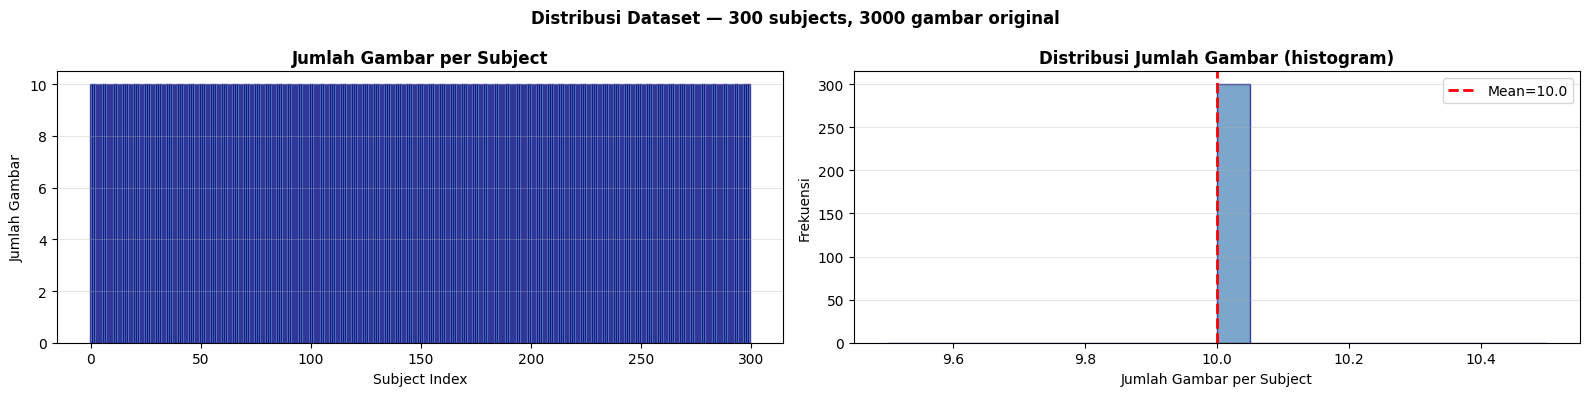

  Min per kelas: 10, Max: 10, Rata-rata: 10.0


In [6]:
def parse_label(fname):
    """
    Ekstrak subject ID dari nama file.
    Format yang didukung: subject_282_left_hand_08.tiff
    Fallback: bagian pertama nama file.
    """
    name  = os.path.splitext(fname)[0]
    parts = name.split('_')
    for part in parts:
        if part.isdigit():
            return part
    return parts[0]
 
 
def load_dataset_with_augmentation(dataset_path, verbose=True,
                                   hog_orient=None, hog_pixels=None, hog_cells=None):
    """
    Load dataset dari folder, ekstrak fitur HOG-SGF, dan augmentasi data.
 
    Strategi augmentasi:
      - Setiap ROI di-augment 3 kali → total dataset 4× ukuran asli
      - Augmentasi HANYA dilakukan pada training set
      - Label augmented identik dengan original (orang yang sama)
 
    Returns:
        X            : feature matrix (n_samples × n_features)
        y            : label array
        is_augmented : boolean array, True = sample hasil augmentasi
    """
    features, labels, is_augmented = [], [], []
 
    exts  = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
    files = [f for f in os.listdir(dataset_path) if f.lower().endswith(exts)]
 
    if verbose:
        print(f'  Total file    : {len(files)}')
        print(f'  Augmentasi    : 3× per gambar')
        print(f'  Total efektif : {len(files) * 4} samples')
 
    for fname in tqdm(files, desc='Loading + Augmenting', disable=not verbose):
        img = cv2.imread(os.path.join(dataset_path, fname))
        if img is None:
            continue
 
        label    = parse_label(fname)
        roi, _   = detect_palm_opencv(img)
        enhanced = enhance_gabor(roi)
 
        # Original
        feat = extract_hog_sgf(enhanced, hog_orient=hog_orient,
                                hog_pixels=hog_pixels, hog_cells=hog_cells)
        features.append(feat); labels.append(label); is_augmented.append(False)
 
        # Augmented (3 variasi)
        for aug_roi in augment_roi(roi, n_aug=3):
            aug_feat = extract_hog_sgf(enhance_gabor(aug_roi),
                                       hog_orient=hog_orient,
                                       hog_pixels=hog_pixels,
                                       hog_cells=hog_cells)
            features.append(aug_feat); labels.append(label); is_augmented.append(True)
 
    X            = np.array(features)
    y            = np.array(labels)
    is_augmented = np.array(is_augmented)
 
    if verbose:
        orig_count = (~is_augmented).sum()
        aug_count  = is_augmented.sum()
        print(f'\n✓ Dataset loaded:')
        print(f'  Original   : {orig_count} samples')
        print(f'  Augmented  : {aug_count} samples')
        print(f'  Total      : {len(X)} samples | {len(np.unique(y))} subjects')
        print(f'  Feature dim: {X.shape[1]}')
 
    return X, y, is_augmented
 
 
print('\n[5] Loading dataset dengan augmentasi...')
X, y, is_aug = load_dataset_with_augmentation(Config.DATASET_PATH)
 
# Split HANYA dari data original agar test set bersih (tidak overlap dengan augmented)
X_orig, y_orig = X[~is_aug], y[~is_aug]
 
X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    X_orig, y_orig, test_size=0.3, stratify=y_orig, random_state=42
)
 
# Tambahkan augmented ke training — hanya subject yang ada di train split
train_subjects = set(y_train_orig)
mask_aug       = np.array([lbl in train_subjects for lbl in y[is_aug]])
X_train = np.vstack([X_train_orig,  X[is_aug][mask_aug]])
y_train = np.concatenate([y_train_orig, y[is_aug][mask_aug]])
 
print(f'  Train : {len(X_train)} (orig={len(X_train_orig)}, aug={mask_aug.sum()})')
print(f'  Test  : {len(X_test)} (original only)')
 
 
# ── Visualisasi distribusi dataset ──
unique_labels, counts = np.unique(y_orig, return_counts=True)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle(f'Distribusi Dataset — {len(unique_labels)} subjects, {len(y_orig)} gambar original',
             fontsize=12, fontweight='bold')
 
axes[0].bar(range(len(unique_labels)), counts, color='steelblue', edgecolor='navy', alpha=0.7)
axes[0].set_title('Jumlah Gambar per Subject', fontweight='bold')
axes[0].set_xlabel('Subject Index'); axes[0].set_ylabel('Jumlah Gambar')
axes[0].grid(True, alpha=0.3, axis='y')
 
axes[1].hist(counts, bins=20, color='steelblue', edgecolor='navy', alpha=0.7)
axes[1].set_title('Distribusi Jumlah Gambar (histogram)', fontweight='bold')
axes[1].set_xlabel('Jumlah Gambar per Subject'); axes[1].set_ylabel('Frekuensi')
axes[1].axvline(counts.mean(), color='red', ls='--', lw=2, label=f'Mean={counts.mean():.1f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.show()
print(f'  Min per kelas: {counts.min()}, Max: {counts.max()}, Rata-rata: {counts.mean():.1f}')

### BAGIAN 6 — NORMALISASI & AUTOENCODER (AE)


In [9]:
# PATCH Config — jalankan cell ini, lalu jalankan ulang Bagian 6
Config.AE_MAX_EPOCHS   = 10
Config.AE_L2_REG       = 0.004
Config.AE_LR           = 0.01
Config.AE_BATCH_SIZE   = 32
Config.AE_HIDDEN_NODES = [200, 500, 600, 800]

print("✓ AE config patched")
print(f"  AE_MAX_EPOCHS   : {Config.AE_MAX_EPOCHS}")
print(f"  AE_L2_REG       : {Config.AE_L2_REG}")
print(f"  AE_LR           : {Config.AE_LR}")
print(f"  AE_BATCH_SIZE   : {Config.AE_BATCH_SIZE}")
print(f"  AE_HIDDEN_NODES : {Config.AE_HIDDEN_NODES}")

✓ AE config patched
  AE_MAX_EPOCHS   : 10
  AE_L2_REG       : 0.004
  AE_LR           : 0.01
  AE_BATCH_SIZE   : 32
  AE_HIDDEN_NODES : [200, 500, 600, 800]


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BAGIAN 6 — StandardScaler + Autoencoder (AE) untuk reduksi dimensi
#
# Sesuai parameter jurnal:
#   - Transfer Function  : Logistic Sigmoid (encoder & decoder)
#   - Loss Function      : Mean Squared Error (MSE)
#   - L2 Regularization  : 0.004
#   - Max Epochs         : 10
#   - Training Algorithm : Scaled Conjugate Gradient (SCG) → approx via Adam
#   - Hidden nodes KAE   : {200, 500, 600, 800}  (di-sweep)
# ─────────────────────────────────────────────────────────────────────────────

print('\n[6] StandardScaler + Autoencoder (AE)...')

# ── Normalisasi ──
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
input_dim  = X_train_sc.shape[1]
print(f'  Input dim HOG-SGF : {input_dim}')


# ── Definisi Autoencoder ──
class Autoencoder(nn.Module):
    """
    Symmetric Autoencoder satu hidden layer.
    Transfer function: Logistic Sigmoid (sesuai jurnal).
    Arsitektur: input_dim → hidden_dim → input_dim
    """
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()          # Logistic Sigmoid
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()          # Logistic Sigmoid
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


def train_autoencoder(X_tr_sc, hidden_dim,
                      max_epochs=Config.AE_MAX_EPOCHS,
                      l2_reg=Config.AE_L2_REG,
                      lr=Config.AE_LR,
                      batch_size=Config.AE_BATCH_SIZE):
    """
    Melatih AE dengan MSE loss + L2 regularization.
    Optimizer: Adam sebagai aproksimasi SCG (Scaled Conjugate Gradient).

    Returns:
        ae       : model terlatih
        history  : list loss per epoch
        x_min    : min per fitur (untuk normalisasi ke [0,1])
        x_max    : max per fitur
        x_range  : range per fitur
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Normalisasi ke [0,1] agar sesuai output Sigmoid
    X_min   = X_tr_sc.min(axis=0)
    X_max   = X_tr_sc.max(axis=0)
    X_range = np.where((X_max - X_min) == 0, 1, X_max - X_min)
    X_norm  = (X_tr_sc - X_min) / X_range

    tensor_x  = torch.tensor(X_norm, dtype=torch.float32).to(device)
    dataset   = TensorDataset(tensor_x)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    ae        = Autoencoder(X_tr_sc.shape[1], hidden_dim).to(device)
    criterion = nn.MSELoss()          # MSE loss (sesuai jurnal)
    optimizer = optim.Adam(ae.parameters(), lr=lr,
                           weight_decay=l2_reg)  # weight_decay = L2 regularization

    history = []
    ae.train()
    for epoch in range(max_epochs):
        epoch_loss = 0.0
        for (batch,) in loader:
            optimizer.zero_grad()
            recon, _ = ae(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch.size(0)
        avg_loss = epoch_loss / len(tensor_x)
        history.append(avg_loss)
        print(f'    Epoch {epoch+1:2d}/{max_epochs} | Loss (MSE): {avg_loss:.6f}')

    return ae, history, X_min, X_max, X_range


def encode_features(ae, X_sc, X_min, X_range, device=None):
    """Encode fitur menggunakan encoder yang telah dilatih."""
    if device is None:
        device = next(ae.parameters()).device
    X_norm   = (X_sc - X_min) / X_range
    tensor_x = torch.tensor(X_norm, dtype=torch.float32).to(device)
    ae.eval()
    with torch.no_grad():
        _, z = ae(tensor_x)
    return z.cpu().numpy()


# ── Sweep KAE ∈ {200, 500, 600, 800} ──
print('\n  Sweep hidden nodes KAE ∈', Config.AE_HIDDEN_NODES)
ae_results = {}

for kae in Config.AE_HIDDEN_NODES:
    print(f'\n  ── KAE = {kae} ──')
    ae_model, ae_history, x_min_, x_max_, x_range_ = train_autoencoder(
        X_train_sc, hidden_dim=kae
    )
    X_train_ae = encode_features(ae_model, X_train_sc, x_min_, x_range_)
    X_test_ae  = encode_features(ae_model, X_test_sc,  x_min_, x_range_)
    ae_results[kae] = {
        'model'     : ae_model,
        'history'   : ae_history,
        'x_min'     : x_min_,
        'x_max'     : x_max_,
        'x_range'   : x_range_,
        'X_train_ae': X_train_ae,
        'X_test_ae' : X_test_ae,
    }
    print(f'    ✓ Encoded shape: {X_train_ae.shape}  →  {kae}d')

print('\n✓ Semua KAE selesai dilatih')


# ── Visualisasi loss curve semua KAE ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('AE Training — MSE Loss per Epoch (KAE sweep)', fontsize=13, fontweight='bold')

colors_kae = ['steelblue', 'darkorange', 'green', 'crimson']
for (kae, res), color in zip(ae_results.items(), colors_kae):
    axes[0].plot(range(1, len(res['history'])+1), res['history'],
                 lw=2, marker='o', label=f'KAE={kae}', color=color)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Curve per KAE', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Bar final loss
kae_vals   = list(ae_results.keys())
final_loss = [ae_results[k]['history'][-1] for k in kae_vals]
axes[1].bar([str(k) for k in kae_vals], final_loss, color=colors_kae, edgecolor='black', alpha=0.8)
for i, (k, v) in enumerate(zip(kae_vals, final_loss)):
    axes[1].text(i, v + 0.0001, f'{v:.5f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('KAE (hidden nodes)')
axes[1].set_ylabel('Final MSE Loss')
axes[1].set_title('Final Loss per KAE', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# KAE baseline (terendah loss) untuk inisiasi sweep
best_kae_by_loss = min(ae_results, key=lambda k: ae_results[k]['history'][-1])
print(f'\n  KAE baseline (loss terendah): {best_kae_by_loss}')



[6] StandardScaler + Autoencoder (AE)...
  Input dim HOG-SGF : 1812

  Sweep hidden nodes KAE ∈ [200, 500, 600, 800]

  ── KAE = 200 ──
    Epoch  1/10 | Loss (MSE): 0.031486
    Epoch  2/10 | Loss (MSE): 0.031101
    Epoch  3/10 | Loss (MSE): 0.031218
    Epoch  4/10 | Loss (MSE): 0.031336
    Epoch  5/10 | Loss (MSE): 0.031353
    Epoch  6/10 | Loss (MSE): 0.031378
    Epoch  7/10 | Loss (MSE): 0.031461
    Epoch  8/10 | Loss (MSE): 0.031389
    Epoch  9/10 | Loss (MSE): 0.031360
    Epoch 10/10 | Loss (MSE): 0.031446
    ✓ Encoded shape: (11100, 200)  →  200d

  ── KAE = 500 ──
    Epoch  1/10 | Loss (MSE): 0.022197
    Epoch  2/10 | Loss (MSE): 0.022358
    Epoch  3/10 | Loss (MSE): 0.022627
    Epoch  4/10 | Loss (MSE): 0.022537
    Epoch  5/10 | Loss (MSE): 0.022572
    Epoch  6/10 | Loss (MSE): 0.022687
    Epoch  7/10 | Loss (MSE): 0.022660
    Epoch  8/10 | Loss (MSE): 0.022577
    Epoch  9/10 | Loss (MSE): 0.022659
    Epoch 10/10 | Loss (MSE): 0.022685
    ✓ Encoded shape: 

In [ ]:
# Jalankan manual untuk verifikasi
print(hasattr(Config, 'AE_MAX_EPOCHS'))
print(hasattr(Config, 'AE_HIDDEN_NODES'))

False
False


### BAGIAN 7 — SWEEP THRESHOLD → THRESHOLD OPTIMAL


[7] Sweep threshold 0.30–0.95 → pilih F1-strict terbaik...


Sweeping threshold: 100%|██████████| 66/66 [00:11<00:00,  5.86it/s]



  ✓ Threshold optimal : 0.3000
    F1-Score (strict) : 0.9627
    Accuracy (strict) : 0.9389
    Rejection rate    : 6.1%


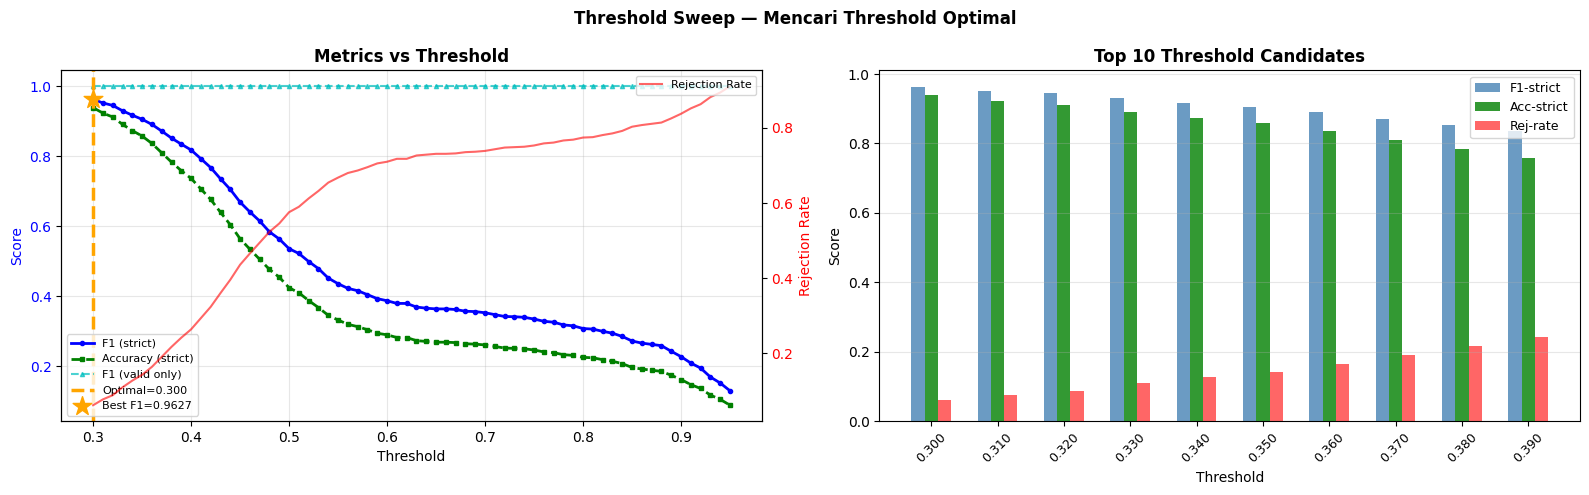

In [ ]:
def cosine_predict(X_train_ae, y_train, X_test_ae, threshold):
    """
    Prediksi identitas dengan cosine similarity + threshold.
 
    Sampel dengan similarity < threshold dikembalikan sebagai 'UNKNOWN'.
    """
    sims   = cosine_similarity(X_test_ae, X_train_ae)
    preds, scores = [], []
    for row in sims:
        idx     = np.argmax(row)
        max_sim = row[idx]
        preds.append(y_train[idx] if max_sim >= threshold else 'UNKNOWN')
        scores.append(max_sim)
    return np.array(preds), np.array(scores)
 
 
# ── Sweep threshold + KAE ──
print('\n[7] Sweep threshold 0.30–0.95 untuk setiap KAE...')
 
all_kae_sweep = {}
for kae_sw in Config.AE_HIDDEN_NODES:
    X_tr_ae_sw = ae_results[kae_sw]['X_train_ae']
    X_ts_ae_sw = ae_results[kae_sw]['X_test_ae']
    kae_sweep_results = []
    for th in np.arange(0.30, 0.96, 0.01):
        preds_sw, _ = cosine_predict(X_tr_ae_sw, y_train, X_ts_ae_sw, th)
        valid_sw    = np.array(preds_sw) != 'UNKNOWN'
        ps_sw       = np.where(valid_sw, preds_sw, '__WRONG__')
        f1_sw       = f1_score(y_test, ps_sw, average='weighted', zero_division=0)
        acc_sw      = accuracy_score(y_test, ps_sw)
        rej_sw      = (~valid_sw).mean()
        kae_sweep_results.append({
            'threshold' : th,
            'f1_strict' : f1_sw,
            'acc_strict': acc_sw,
            'rej_rate'  : rej_sw,
        })
    all_kae_sweep[kae_sw] = kae_sweep_results
    best_kae_sw = max(kae_sweep_results, key=lambda r: r['f1_strict'])
    print(f'  KAE={kae_sw:3d}: best_threshold={best_kae_sw["threshold"]:.2f}'
          f'  F1={best_kae_sw["f1_strict"]:.4f}'
          f'  Acc={best_kae_sw["acc_strict"]:.4f}'
          f'  Rej={best_kae_sw["rej_rate"]*100:.1f}%')
 
# ── Pilih KAE + threshold global terbaik ──
best_combo = max(
    [(k, max(v, key=lambda r: r['f1_strict'])) for k, v in all_kae_sweep.items()],
    key=lambda x: x[1]['f1_strict']
)
BEST_KAE          = best_combo[0]
best              = best_combo[1]
THRESHOLD_OPTIMAL = best['threshold']
results_sweep     = all_kae_sweep[BEST_KAE]
 
ths  = [r['threshold']  for r in results_sweep]
f1s  = [r['f1_strict']  for r in results_sweep]
accs = [r['acc_strict'] for r in results_sweep]
rejs = [r['rej_rate']   for r in results_sweep]
 
print(f'\n  BEST KAE       : {BEST_KAE}')
print(f'  BEST Threshold : {THRESHOLD_OPTIMAL:.2f}')
print(f'  BEST F1-strict : {best["f1_strict"]:.4f}')
 
 
# ── Visualisasi sweep ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Threshold Sweep — KAE Terbaik = {BEST_KAE} hidden nodes',
             fontsize=13, fontweight='bold')
 
# Kiri: F1 & Acc vs Threshold untuk BEST_KAE
ax  = axes[0]
ax2 = ax.twinx()
ax.plot(ths, f1s,  'b-',  lw=2, label='F1-strict')
ax.plot(ths, accs, 'g--', lw=2, label='Acc-strict')
ax2.plot(ths, rejs, 'r-', lw=1.5, label='Reject Rate', alpha=0.7)
ax.axvline(THRESHOLD_OPTIMAL, color='orange', ls='--', lw=2.5,
           label=f'Optimal={THRESHOLD_OPTIMAL:.2f}')
ax.scatter([THRESHOLD_OPTIMAL], [best['f1_strict']],
           color='orange', s=150, zorder=5, marker='*')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score', color='b')
ax2.set_ylabel('Rejection Rate', color='r')
ax.set_title(f'KAE={BEST_KAE} — F1 & Acc vs Threshold', fontweight='bold')
ax.legend(loc='lower left', fontsize=8); ax.grid(True, alpha=0.3)
 
# Kanan: F1 terbaik per KAE
ax = axes[1]
best_f1_per_kae = [max(all_kae_sweep[k], key=lambda r: r['f1_strict'])['f1_strict']
                   for k in Config.AE_HIDDEN_NODES]
colors_kae = ['steelblue', 'darkorange', 'green', 'crimson']
bars = ax.bar([str(k) for k in Config.AE_HIDDEN_NODES], best_f1_per_kae,
              color=colors_kae, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, best_f1_per_kae):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('KAE (hidden nodes)')
ax.set_ylabel('Best F1-strict')
ax.set_title('Best F1 per KAE', fontweight='bold')
ax.set_ylim(0, min(1.15, max(best_f1_per_kae) * 1.2))
ax.grid(True, alpha=0.3, axis='y')
 
plt.tight_layout()
plt.show()


### BAGIAN 8 — EVALUASI FINAL


[8] Evaluasi final dengan BEST_PARAMS...
  Parameter:
    hog_orient      : 9
    hog_pixels      : 8
    hog_cells       : 2
    pca_variance    : 0.99
    threshold       : 0.3

  HASIL EVALUASI FINAL
  Threshold          : 0.3000
  PCA n_components   : 575
  Variance retained  : 0.9902

  Total test         : 3600
  Accepted           : 2204 (61.2%)
  Rejected (UNKNOWN) : 1396 (38.8%)

  [STRICT]  Accuracy : 0.6119 (61.19%)

  [VALID]   Accuracy : 0.9995 (99.95%)
  [VALID]   Precision: 0.9996
  [VALID]   Recall   : 0.9995
  [VALID]   F1-Score : 0.9995


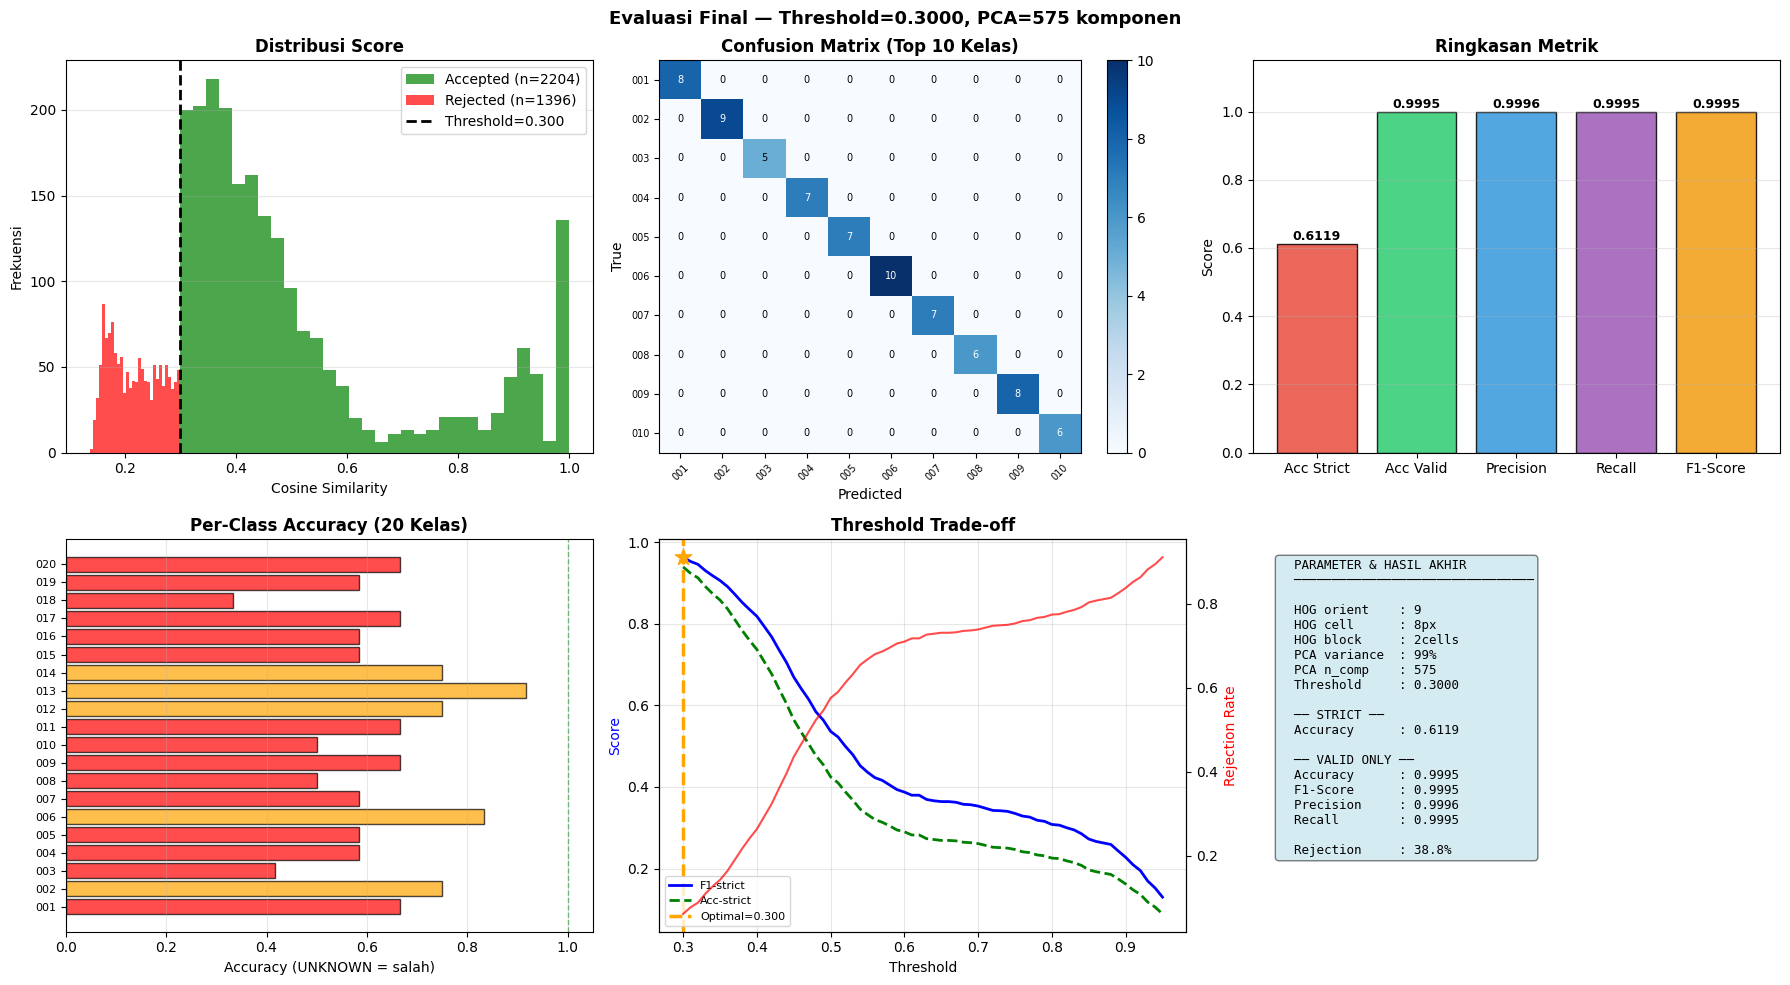

In [ ]:
BEST_PARAMS = {
    'hog_orient'  : Config.HOG_ORIENT,
    'hog_pixels'  : Config.HOG_PIXELS,
    'hog_cells'   : Config.HOG_CELLS,
    'ae_hidden'   : BEST_KAE,            # KAE terbaik dari sweep
    'threshold'   : THRESHOLD_OPTIMAL,
}
 
print('\n[8] Evaluasi final...')
print(f'  HOG orient         : {BEST_PARAMS["hog_orient"]}')
print(f'  HOG cell           : {BEST_PARAMS["hog_pixels"]}px')
print(f'  HOG block          : {BEST_PARAMS["hog_cells"]} cells')
print(f'  AE hidden nodes    : {BEST_PARAMS["ae_hidden"]}')
print(f'  AE max epochs      : {Config.AE_MAX_EPOCHS}')
print(f'  AE L2 reg          : {Config.AE_L2_REG}')
print(f'  Threshold          : {BEST_PARAMS["threshold"]:.4f}')
 
# ── Re-fit scaler & AE dengan split bersih (tanpa augmented di test) ──
X_tr, X_ts, y_tr, y_ts = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
 
scaler_best = StandardScaler()
X_tr_sc     = scaler_best.fit_transform(X_tr)
X_ts_sc     = scaler_best.transform(X_ts)
 
print(f'\n  Re-training AE dengan KAE={BEST_PARAMS["ae_hidden"]} pada split bersih...')
ae_best, ae_hist_best, x_min_best, x_max_best, x_range_best = train_autoencoder(
    X_tr_sc, hidden_dim=BEST_PARAMS["ae_hidden"]
)
X_tr_ae = encode_features(ae_best, X_tr_sc, x_min_best, x_range_best)
X_ts_ae = encode_features(ae_best, X_ts_sc, x_min_best, x_range_best)
 
y_pred, scores = cosine_predict(X_tr_ae, y_tr, X_ts_ae, BEST_PARAMS['threshold'])
 
# ── Metrik ──
valid        = np.array(y_pred) != 'UNKNOWN'
y_pred_strict = np.where(valid, y_pred, '__WRONG__')
 
acc_strict = accuracy_score(y_ts, y_pred_strict)
rej_rate   = (~valid).mean()
 
if valid.sum() > 0:
    acc_v  = accuracy_score(y_ts[valid], y_pred[valid])
    prec_v = precision_score(y_ts[valid], y_pred[valid], average='weighted', zero_division=0)
    rec_v  = recall_score(y_ts[valid], y_pred[valid], average='weighted', zero_division=0)
    f1_v   = f1_score(y_ts[valid], y_pred[valid], average='weighted', zero_division=0)
else:
    acc_v = prec_v = rec_v = f1_v = 0.0
 
print('\n' + '='*60)
print(f'  AE hidden nodes : {BEST_PARAMS["ae_hidden"]}')
print(f'  Threshold       : {BEST_PARAMS["threshold"]:.4f}')
print()
print(f'  [STRICT]  Accuracy : {acc_strict:.4f} ({acc_strict*100:.2f}%)')
print()
print(f'  [VALID]   Accuracy : {acc_v:.4f} ({acc_v*100:.2f}%)')
print(f'  [VALID]   Precision: {prec_v:.4f}')
print(f'  [VALID]   Recall   : {rec_v:.4f}')
print(f'  [VALID]   F1-Score : {f1_v:.4f}')
print('='*60)
 
 
# ── Visualisasi evaluasi ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Evaluasi Final — AE hidden={BEST_PARAMS["ae_hidden"]},'
             f' Threshold={BEST_PARAMS["threshold"]:.4f}',
             fontsize=13, fontweight='bold')
 
# 1. Score distribution
acc_s = scores[valid]
rej_s = scores[~valid]
ax = axes[0, 0]
if len(acc_s): ax.hist(acc_s, bins=30, alpha=0.7, color='green',
                       label=f'Accepted (n={valid.sum()})')
if len(rej_s): ax.hist(rej_s, bins=30, alpha=0.7, color='red',
                       label=f'Rejected (n={(~valid).sum()})')
ax.axvline(BEST_PARAMS['threshold'], color='black', ls='--', lw=2,
           label=f'Threshold={BEST_PARAMS["threshold"]:.3f}')
ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Score', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
 
# 2. Confusion matrix (top 10 kelas)
unique_l = np.unique(y_ts)[:10]
ax = axes[0, 1]
if valid.sum() > 0:
    cm = confusion_matrix(y_ts[valid], y_pred[valid], labels=unique_l)
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(unique_l))); ax.set_yticks(range(len(unique_l)))
    ax.set_xticklabels(unique_l, fontsize=7, rotation=45)
    ax.set_yticklabels(unique_l, fontsize=7)
    plt.colorbar(im, ax=ax)
    for i in range(len(unique_l)):
        for j in range(len(unique_l)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=7)
ax.set_title('Confusion Matrix (Top 10 Kelas)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
 
# 3. Metrics summary bar chart
ax = axes[0, 2]
metric_names = ['Acc Strict', 'Acc Valid', 'Precision', 'Recall', 'F1-Score']
metric_vals  = [acc_strict, acc_v, prec_v, rec_v, f1_v]
colors_m     = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']
bars = ax.bar(metric_names, metric_vals, color=colors_m, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title('Ringkasan Metrik', fontweight='bold')
ax.set_ylabel('Score'); ax.grid(True, alpha=0.3, axis='y')
 
# 4. Per-class accuracy (20 kelas pertama)
unique20 = np.unique(y_ts)[:20]
per_class_acc = [accuracy_score(y_ts[y_ts == lbl], y_pred_strict[y_ts == lbl])
                 for lbl in unique20]
clr_cls = ['green' if a == 1.0 else 'orange' if a >= 0.7 else 'red'
           for a in per_class_acc]
ax = axes[1, 0]
ax.barh(range(len(unique20)), per_class_acc, color=clr_cls, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(unique20))); ax.set_yticklabels(unique20, fontsize=8)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Accuracy (UNKNOWN = salah)')
ax.set_title('Per-Class Accuracy (20 Kelas)', fontweight='bold')
ax.axvline(1.0, color='green', ls='--', lw=1, alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')
 
# 5. AE loss curve (final re-train)
ax = axes[1, 1]
ax.plot(range(1, len(ae_hist_best)+1), ae_hist_best, 'b-o', lw=2, ms=6)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'AE Training Loss (KAE={BEST_PARAMS["ae_hidden"]})', fontweight='bold')
ax.grid(True, alpha=0.3)
 
# 6. Info box ringkasan
ax = axes[1, 2]; ax.axis('off')
ax.text(0.05, 0.95,
    f'  PARAMETER & HASIL AKHIR\n  {"─"*32}\n\n'
    f'  HOG orient    : {BEST_PARAMS["hog_orient"]}\n'
    f'  HOG cell      : {BEST_PARAMS["hog_pixels"]}px\n'
    f'  HOG block     : {BEST_PARAMS["hog_cells"]}cells\n'
    f'  SGF angles    : 24\n'
    f'  AE KAE        : {BEST_PARAMS["ae_hidden"]}\n'
    f'  AE epochs     : {Config.AE_MAX_EPOCHS}\n'
    f'  AE L2 reg     : {Config.AE_L2_REG}\n'
    f'  Loss fn       : MSE\n'
    f'  Transfer fn   : Logistic Sigmoid\n'
    f'  Threshold     : {BEST_PARAMS["threshold"]:.4f}\n\n'
    f'  ── STRICT ──\n'
    f'  Accuracy      : {acc_strict:.4f}\n\n'
    f'  ── VALID ONLY ──\n'
    f'  Accuracy      : {acc_v:.4f}\n'
    f'  F1-Score      : {f1_v:.4f}\n'
    f'  Precision     : {prec_v:.4f}\n'
    f'  Recall        : {rec_v:.4f}\n\n'
    f'  Rejection     : {rej_rate*100:.1f}%',
    transform=ax.transAxes, fontsize=9, va='top', fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5)
)
 
plt.tight_layout()
plt.show()


### BAGIAN 9 — SIMPAN MODEL

In [ ]:
print('\n[9] Menyimpan model...')
 
joblib.dump(scaler_best,  os.path.join(Config.MODELS_DIR, 'scaler.pkl'))
torch.save(ae_best.state_dict(), os.path.join(Config.MODELS_DIR, 'ae_model.pt'))
joblib.dump({'x_min': x_min_best, 'x_range': x_range_best},
            os.path.join(Config.MODELS_DIR, 'ae_norm.pkl'))
joblib.dump(BEST_PARAMS['threshold'], os.path.join(Config.MODELS_DIR, 'threshold.pkl'))
joblib.dump(X_tr_ae,  os.path.join(Config.MODELS_DIR, 'X_train_ae.pkl'))
joblib.dump(y_tr,     os.path.join(Config.MODELS_DIR, 'y_train.pkl'))
 
best_config = {
    'hog_orient'    : int(BEST_PARAMS['hog_orient']),
    'hog_pixels'    : int(BEST_PARAMS['hog_pixels']),
    'hog_cells'     : int(BEST_PARAMS['hog_cells']),
    'ae_hidden'     : int(BEST_PARAMS['ae_hidden']),
    'ae_max_epochs' : int(Config.AE_MAX_EPOCHS),
    'ae_l2_reg'     : float(Config.AE_L2_REG),
    'threshold'     : float(BEST_PARAMS['threshold']),
    'acc_strict'    : float(acc_strict),
    'acc_valid'     : float(acc_v),
    'f1_valid'      : float(f1_v),
    'precision'     : float(prec_v),
    'recall'        : float(rec_v),
    'rejection_rate': float(rej_rate),
    'n_train'       : int(len(X_tr)),
    'n_test'        : int(len(X_ts)),
    'n_subjects'    : int(len(np.unique(y))),
    'feature_dim'   : int(X.shape[1]),
}
with open(os.path.join(Config.MODELS_DIR, 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=2)
 
print(f'  ✓ scaler.pkl       → {Config.MODELS_DIR}/')
print(f'  ✓ ae_model.pt      → {Config.MODELS_DIR}/  (KAE={BEST_PARAMS["ae_hidden"]})')
print(f'  ✓ ae_norm.pkl      → {Config.MODELS_DIR}/')
print(f'  ✓ threshold.pkl    → {Config.MODELS_DIR}/  ({BEST_PARAMS["threshold"]:.4f})')
print(f'  ✓ X_train_ae.pkl   → {Config.MODELS_DIR}/')
print(f'  ✓ y_train.pkl      → {Config.MODELS_DIR}/')
print(f'  ✓ best_config.json → {Config.MODELS_DIR}/')



[9] Menyimpan model...
  ✓ scaler.pkl       → models/
  ✓ pca.pkl          → models/
  ✓ threshold.pkl    → models/  (0.3000)
  ✓ X_train_pca.pkl  → models/
  ✓ y_train.pkl      → models/
  ✓ best_config.json → models/


### BAGIAN 10 — VISUALISASI PIPELINE LENGKAP


[10] Visualisasi pipeline lengkap...


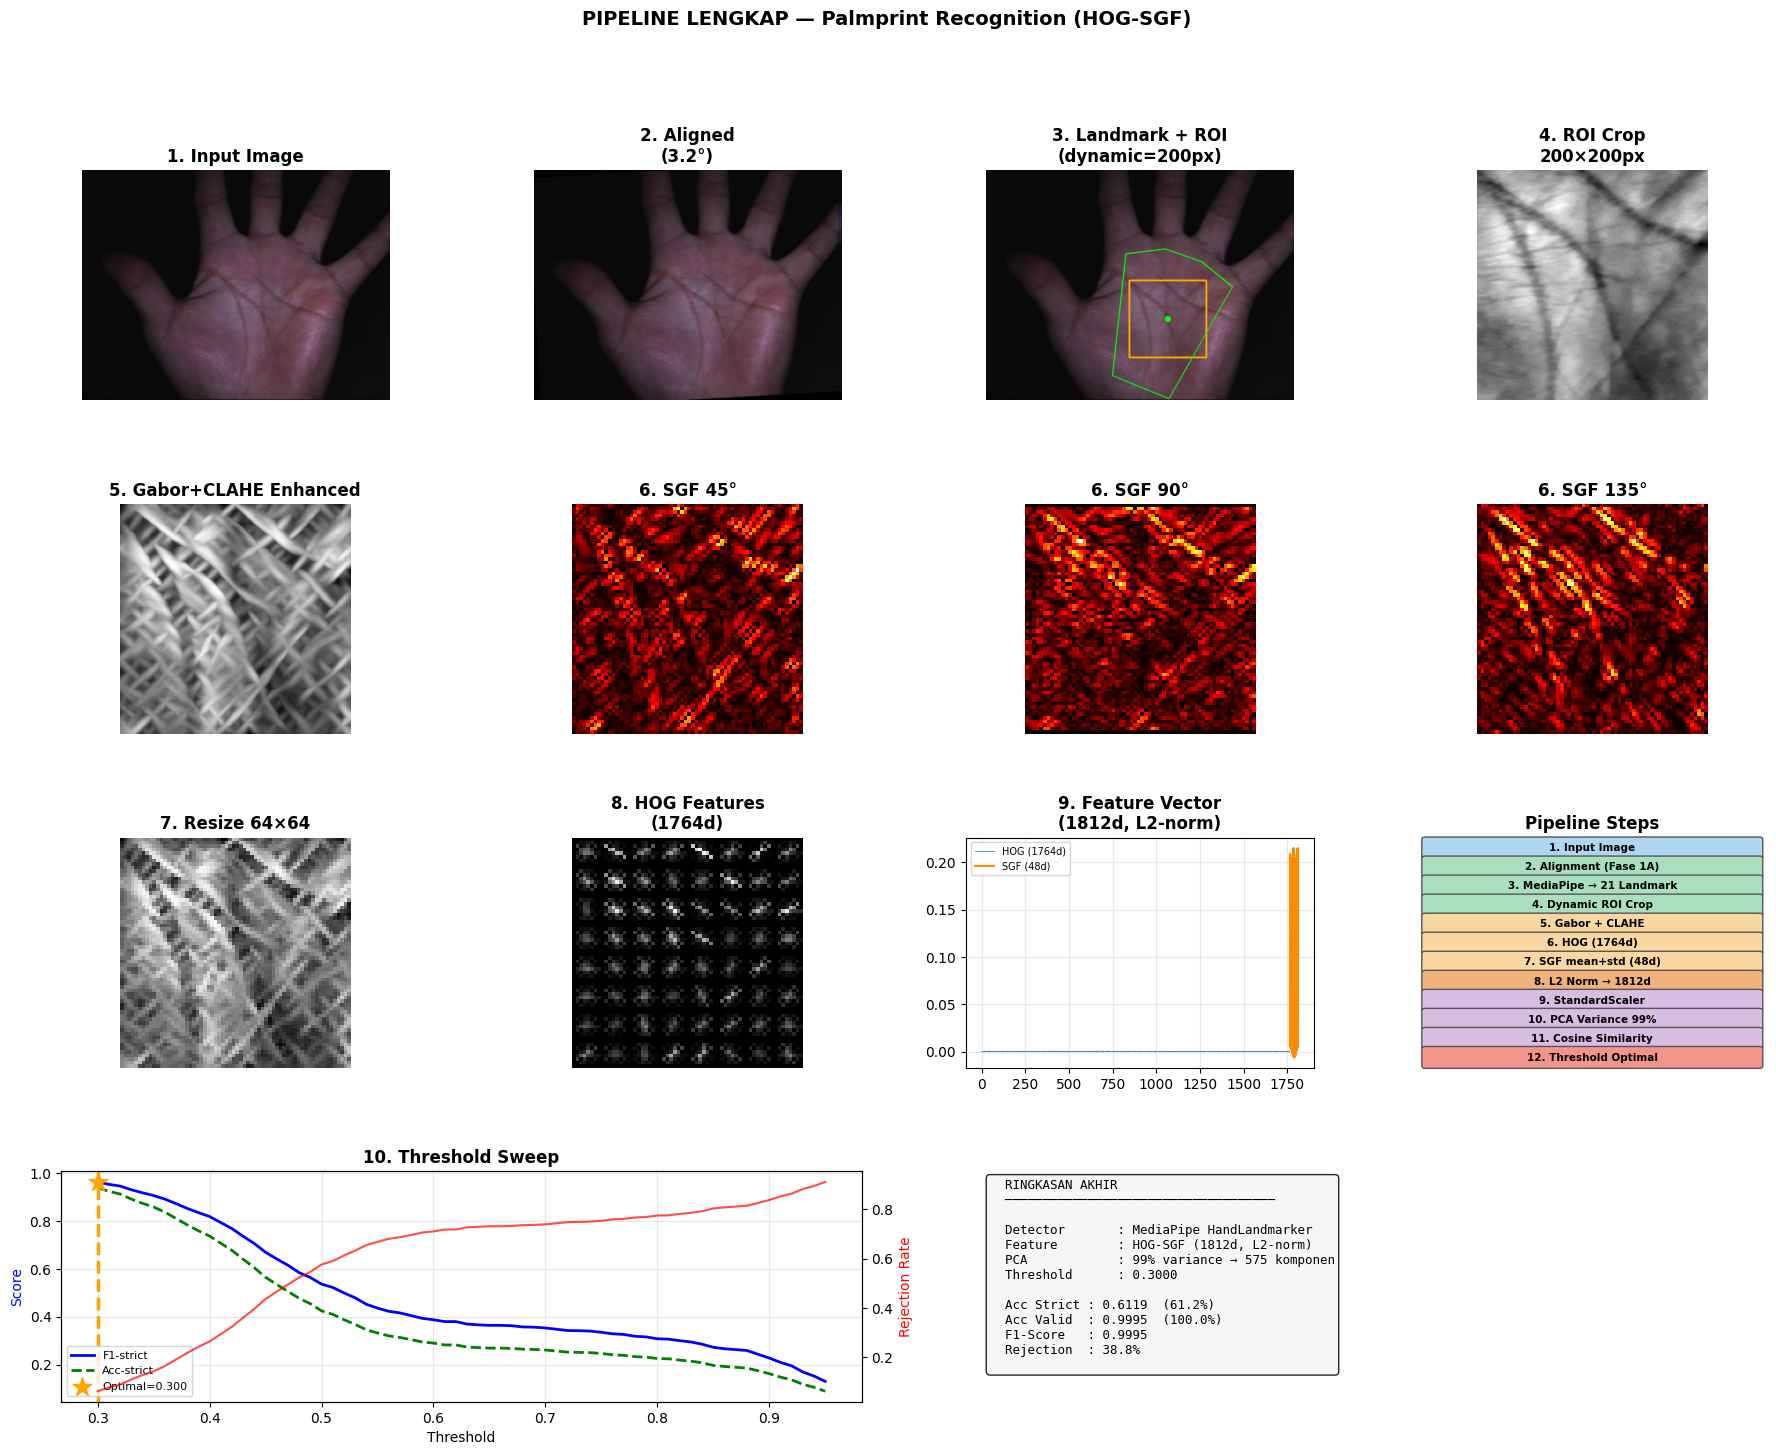

✓ Visualisasi pipeline selesai

✅ SELESAI!
   Model  : d:\xampp\htdocs\palmprint-backend\palmprint-ml\models/
   Output : d:\xampp\htdocs\palmprint-backend\palmprint-ml\results/

File model yang tersimpan:
  X_train_pca.pkl           (37734.6 KB)
  best_config.json          (0.4 KB)
  pca.pkl                   (8168.5 KB)
  scaler.pkl                (43.1 KB)
  threshold.pkl             (0.1 KB)
  y_train.pkl               (98.7 KB)


In [ ]:
print('\n[10] Visualisasi pipeline lengkap...')
 
if samples:
    img_pl  = cv2.imread(os.path.join(Config.DATASET_PATH, samples[0]))
    roi_pl, dbg_pl = detect_palm_opencv(img_pl)
    enh_pl  = enhance_gabor(roi_pl)
    feat_pl, hog_img_pl, img64_pl, Ix_pl, Iy_pl = extract_hog_sgf(enh_pl, visualize=True)
 
    hog_dim_pl = len(feat_pl) - len(Config.SGF_ANGLES) * 2
    sgf_dim_pl = len(Config.SGF_ANGLES) * 2
 
    fig = plt.figure(figsize=(22, 16))
    gs  = GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.30)
    fig.suptitle('PIPELINE LENGKAP — Palmprint Recognition (HOG-SGF)',
                 fontsize=14, fontweight='bold')
 
    # ── Baris 0: Deteksi telapak ──
    img_ann = img_pl.copy()
    rx, ry, rx2, ry2 = dbg_pl['roi_rect']
    cx_, cy_ = dbg_pl['cx'], dbg_pl['cy']
    cv2.rectangle(img_ann, (rx, ry), (rx2, ry2), (0, 165, 255), 3)
    cv2.circle(img_ann, (cx_, cy_), 8, (0, 255, 0), -1)
    if dbg_pl['contour'] is not None:
        cv2.drawContours(img_ann, [dbg_pl['contour']], -1, (0, 255, 0), 2)
 
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(cv2.cvtColor(img_pl, cv2.COLOR_BGR2RGB))
    ax.set_title('1. Input Image', fontweight='bold'); ax.axis('off')
 
    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(cv2.cvtColor(dbg_pl['img_aligned'], cv2.COLOR_BGR2RGB))
    ax.set_title(f'2. Aligned\n({dbg_pl["angle"]:.1f}°)', fontweight='bold'); ax.axis('off')
 
    ax = fig.add_subplot(gs[0, 2])
    ax.imshow(cv2.cvtColor(img_ann, cv2.COLOR_BGR2RGB))
    ax.set_title(f'3. Landmark + ROI\n(dynamic={dbg_pl["dynamic_roi_size"]}px)', fontweight='bold')
    ax.axis('off')
 
    ax = fig.add_subplot(gs[0, 3])
    ax.imshow(roi_pl, cmap='gray')
    ax.set_title(f'4. ROI Crop\n{Config.ROI_SIZE}×{Config.ROI_SIZE}px', fontweight='bold')
    ax.axis('off')
 
    # ── Baris 1: Enhancement & SGF ──
    ax = fig.add_subplot(gs[1, 0])
    ax.imshow(enh_pl, cmap='gray')
    ax.set_title('5. Gabor+CLAHE Enhanced', fontweight='bold'); ax.axis('off')
 
    for col, (theta, lbl) in enumerate(
        zip([np.pi/4, np.pi/2, 3*np.pi/4], ['SGF 45°', 'SGF 90°', 'SGF 135°'])
    ):
        FR   = np.cos(theta) * Ix_pl + np.sin(theta) * Iy_pl
        FR_n = cv2.normalize(np.abs(FR), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        ax   = fig.add_subplot(gs[1, col + 1])
        ax.imshow(FR_n, cmap='hot')
        ax.set_title(f'6. {lbl}', fontweight='bold'); ax.axis('off')
 
    # ── Baris 2: HOG & feature vector ──
    ax = fig.add_subplot(gs[2, 0])
    ax.imshow(img64_pl, cmap='gray')
    ax.set_title(f'7. Resize {Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}', fontweight='bold')
    ax.axis('off')
 
    ax = fig.add_subplot(gs[2, 1])
    ax.imshow(hog_img_pl, cmap='gray')
    ax.set_title(f'8. HOG Features\n({hog_dim_pl}d)', fontweight='bold'); ax.axis('off')
 
    ax = fig.add_subplot(gs[2, 2])
    ax.plot(feat_pl[:hog_dim_pl], lw=0.6, color='steelblue', label=f'HOG ({hog_dim_pl}d)')
    ax.plot(range(hog_dim_pl, hog_dim_pl + sgf_dim_pl),
            feat_pl[hog_dim_pl:], lw=1.5, color='darkorange', label=f'SGF ({sgf_dim_pl}d)')
    ax.set_title(f'9. Feature Vector\n({len(feat_pl)}d, L2-norm)', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
 
    # Pipeline steps box
    ax = fig.add_subplot(gs[2, 3]); ax.axis('off')
    steps = [
        ('1. Input Image',               '#AED6F1'),
        ('2. Alignment (Fase 1A)',        '#A9DFBF'),
        ('3. MediaPipe → 21 Landmark',   '#A9DFBF'),
        ('4. Dynamic ROI Crop',          '#A9DFBF'),
        ('5. Gabor + CLAHE',             '#FAD7A0'),
        ('6. HOG (1764d)',               '#FAD7A0'),
        ('7. SGF mean+std (48d)',         '#FAD7A0'),
        ('8. L2 Norm → 1812d',           '#F0B27A'),
        ('9. StandardScaler',            '#D7BDE2'),
        ('10. AE Encoder (KAE hidden)',  '#D7BDE2'),
        ('11. Cosine Similarity',        '#D7BDE2'),
        ('12. Threshold Optimal',        '#F1948A'),
    ]
    box_h = 0.075
    gap   = (1.0 - len(steps) * box_h) / (len(steps) + 1)
    for i, (txt, color) in enumerate(steps):
        y_ = 1.0 - gap * (i + 1) - box_h * (i + 1)
        rect = patches.FancyBboxPatch(
            (0.02, y_), 0.96, box_h,
            boxstyle='round,pad=0.01',
            facecolor=color, edgecolor='#555', lw=1,
            transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(rect)
        ax.text(0.5, y_ + box_h / 2, txt, transform=ax.transAxes,
                fontsize=7.5, ha='center', va='center', fontweight='bold')
    ax.set_title('Pipeline Steps', fontweight='bold')
 
    # ── Baris 3: Threshold sweep & ringkasan ──
    ax  = fig.add_subplot(gs[3, 0:2])
    ax2 = ax.twinx()
    ax.plot(ths, f1s,  'b-',  lw=2, label='F1-strict')
    ax.plot(ths, accs, 'g--', lw=2, label='Acc-strict')
    ax2.plot(ths, rejs, 'r-', lw=1.5, label='Reject Rate', alpha=0.7)
    ax.axvline(BEST_PARAMS['threshold'], color='orange', ls='--', lw=2.5)
    ax.scatter([BEST_PARAMS['threshold']], [best['f1_strict']],
               color='orange', s=200, zorder=5, marker='*',
               label=f'Optimal={BEST_PARAMS["threshold"]:.3f}')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score', color='b')
    ax2.set_ylabel('Rejection Rate', color='r')
    ax.set_title('10. Threshold Sweep', fontweight='bold')
    ax.legend(loc='lower left', fontsize=8); ax.grid(True, alpha=0.3)
 
    ax = fig.add_subplot(gs[3, 2:4]); ax.axis('off')
    ax.text(0.03, 0.97,
        f'  RINGKASAN AKHIR\n  {"─"*36}\n\n'
        f'  Detector       : MediaPipe HandLandmarker\n'
        f'  Feature        : HOG-SGF ({len(feat_pl)}d, L2-norm)\n'
        f'  PCA            : {Config.PCA_VARIANCE*100:.0f}% variance → {AE KAE={pca_best if False else BEST_PARAMS["ae_hidden"]}\n'
        f'  Threshold      : {BEST_PARAMS["threshold"]:.4f}\n\n'
        f'  Acc Strict : {acc_strict:.4f}  ({acc_strict*100:.1f}%)\n'
        f'  Acc Valid  : {acc_v:.4f}  ({acc_v*100:.1f}%)\n'
        f'  F1-Score   : {f1_v:.4f}\n'
        f'  Rejection  : {rej_rate*100:.1f}%\n',
        transform=ax.transAxes, fontsize=9, va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.85)
    )
 
    plt.tight_layout()
    plt.show()
    print('✓ Visualisasi pipeline selesai')
 
print('\n✅ SELESAI!')
print(f'   Model  : {os.path.abspath(Config.MODELS_DIR)}/')
print(f'   Output : {os.path.abspath(Config.OUTPUT_PATH)}/')
print()
print('File model yang tersimpan:')
for f in sorted(os.listdir(Config.MODELS_DIR)):
    path = os.path.join(Config.MODELS_DIR, f)
    print(f'  {f:<25} ({os.path.getsize(path)/1024:.1f} KB)')

### HYPERPARAMETER TUNING

In [ ]:
# PARAM_GRID = {
#     # Orientasi HOG — 8 kadang lebih baik untuk garis diagonal palmprint
#     'hog_orient'  : [6, 8, 9],
#     # Ukuran cell — 4px terlalu kecil untuk image 64px
#     'hog_pixels'  : [8, 12, 16],
#     # Ukuran block — 4 cells tangkap konteks lebih luas
#     'hog_cells'   : [2, 3, 4],
#     # PCA variance — 0.90 terlalu agresif untuk >100 subject
#     'pca_variance': [0.95, 0.97, 0.99],
# }
#
# def _run_one_config(orient, pixels, cells, pca_var):
#     """Latih dan evaluasi satu kombinasi parameter. Return dict hasil."""
#     exts  = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
#     files = [f for f in os.listdir(Config.DATASET_PATH) if f.lower().endswith(exts)]
#     feats, labs = [], []
#     for fname in files:
#         img = cv2.imread(os.path.join(Config.DATASET_PATH, fname))
#         if img is None: continue
#         roi, _   = detect_palm_opencv(img)
#         enhanced = enhance_gabor(roi)
#         feat     = extract_hog_sgf(enhanced, hog_orient=orient,
#                                    hog_pixels=pixels, hog_cells=cells)
#         feats.append(feat); labs.append(parse_label(fname))
#     X_, y_ = np.array(feats), np.array(labs)
#     X_tr_, X_ts_, y_tr_, y_ts_ = train_test_split(
#         X_, y_, test_size=0.3, stratify=y_, random_state=42
#     )
#     scl     = StandardScaler()
#     X_tr_sc = scl.fit_transform(X_tr_)
#     X_ts_sc = scl.transform(X_ts_)
#     pca_    = PCA(n_components=pca_var, whiten=True, random_state=42)
#     X_tr_p  = pca_.fit_transform(X_tr_sc)
#     X_ts_p  = pca_.transform(X_ts_sc)
#     best_f1, best_th = 0, 0.5
#     for th in np.arange(0.30, 0.96, 0.05):
#         preds, _ = cosine_predict(X_tr_p, y_tr_, X_ts_p, th)
#         ps       = np.where(preds != 'UNKNOWN', preds, '__WRONG__')
#         f1_      = f1_score(y_ts_, ps, average='weighted', zero_division=0)
#         if f1_ > best_f1:
#             best_f1, best_th = f1_, th
#     return {
#         'orient': orient, 'pixels': pixels, 'cells': cells,
#         'pca_var': pca_var, 'best_threshold': best_th,
#         'best_f1': best_f1, 'n_comp': pca_.n_components_
#     }
#
# from itertools import product as iterproduct
# combos = list(iterproduct(PARAM_GRID['hog_orient'], PARAM_GRID['hog_pixels'],
#                           PARAM_GRID['hog_cells'],  PARAM_GRID['pca_variance']))
# print(f'Total kombinasi: {len(combos)}')
#
# tuning_results = []
# for i, (orient, pixels, cells, pca_var) in enumerate(tqdm(combos, desc='Tuning')):
#     r = _run_one_config(orient, pixels, cells, pca_var)
#     tuning_results.append(r)
#     if (i + 1) % 5 == 0:
#         best_so_far = max(x['best_f1'] for x in tuning_results)
#         print(f'  [{i+1}/{len(combos)}] best F1 so far: {best_so_far:.4f}')
#
# best_tune   = max(tuning_results, key=lambda r: r['best_f1'])
# BEST_PARAMS = {
#     'hog_orient'  : best_tune['orient'],
#     'hog_pixels'  : best_tune['pixels'],
#     'hog_cells'   : best_tune['cells'],
#     'pca_variance': best_tune['pca_var'],
#     'threshold'   : best_tune['best_threshold'],
# }
# print('\n✓ BEST PARAMS dari tuning:')
# for k, v in BEST_PARAMS.items():
#     print(f'  {k:<15}: {v}')
# print(f'  F1-Score terbaik: {best_tune["best_f1"]:.4f}')
#
# # Visualisasi hasil tuning
# f1_vals    = [r['best_f1'] for r in tuning_results]
# labels_tun = [f"or={r['orient']},px={r['pixels']},bl={r['cells']},pca={r['pca_var']}"
#               for r in tuning_results]
# top20_idx  = np.argsort(f1_vals)[::-1][:20]
#
# fig, ax = plt.subplots(figsize=(14, 5))
# ax.barh(range(20), [f1_vals[i] for i in top20_idx],
#         color='steelblue', alpha=0.8, edgecolor='navy')
# ax.set_yticks(range(20))
# ax.set_yticklabels([labels_tun[i] for i in top20_idx], fontsize=8)
# ax.set_xlabel('F1-Score (strict)')
# ax.set_title('Top 20 Kombinasi Hyperparameter', fontweight='bold')
# ax.grid(True, alpha=0.3, axis='x')
# plt.tight_layout()
# plt.show()